              precision    recall  f1-score   support

     healing       0.67      1.00      0.80         2
 Not-healing       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



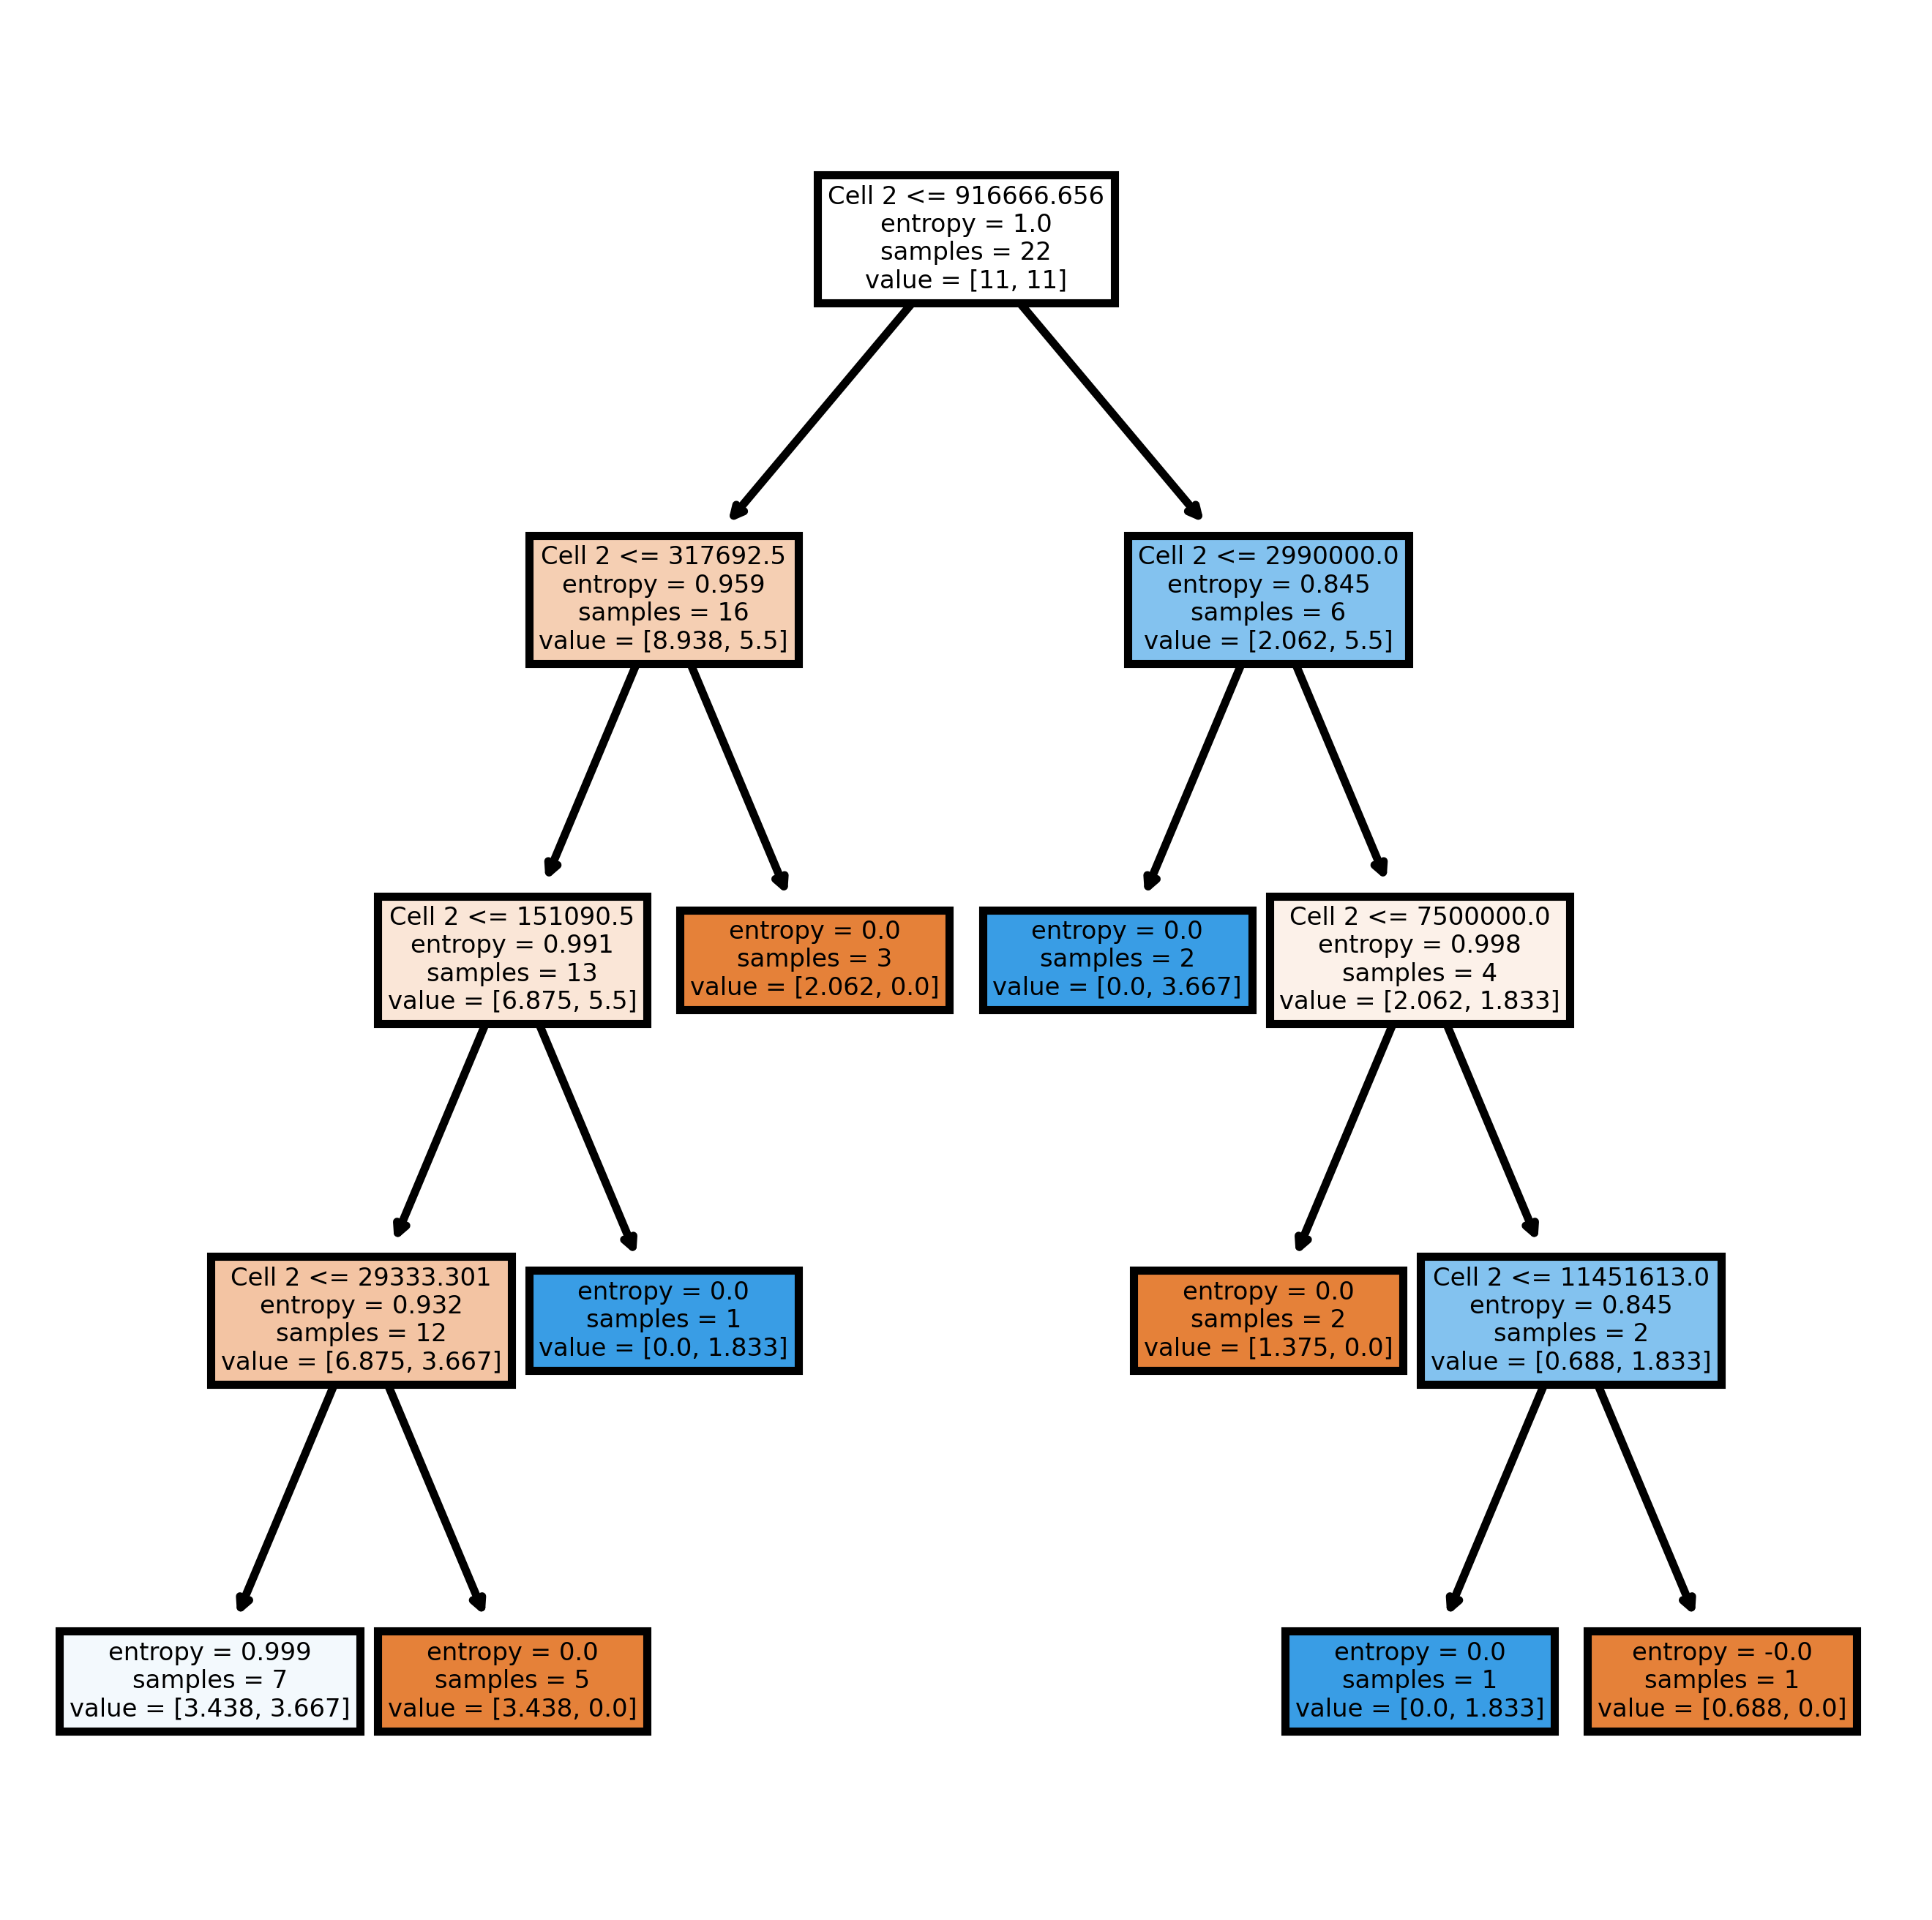

Accuracy: 83.33333333333334 %


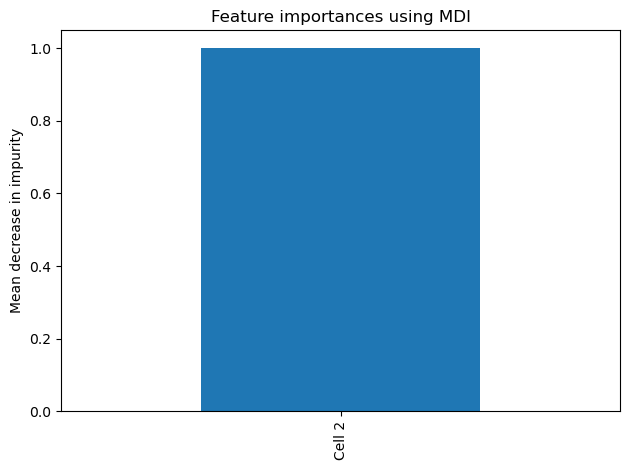

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from xgboost import *
from dtreeviz import model

name="Cell 2.txt"
W_tree=4
class_names=["healing","non-healing"]

Treatment=pd.read_csv("../AD report/Cell 2 train.csv")
Treatment_test=pd.read_csv("../AD report/Cell 2 test.csv")

X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]

clf=DecisionTreeClassifier(max_depth=4,
                            class_weight="balanced",
                               criterion="entropy",
                             #  ccp_alpha=0.06,
                           random_state=5,
                  
    )

names=["Cell 2"]

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(clf, filled = True,feature_names=names);
plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()
target = 'key'
class_names=["non-healing","healing"]

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_train, 
    y_train, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree()